# 13 — Fraud Detection Model

## Business objective

Build a **fraud-alert model** that identifies claims that should be sent for human fraud investigation.

**Target**
- `0` = No fraud alert
- `1` = `Suspected` or `Confirmed`

> Important: this model is a **risk-screening model**, not proof of fraud.  
> A high score should trigger **human investigation**, not automatic claim rejection.

### Leakage rules

We deliberately exclude:
- `FRAUD_FLAG` → target source
- `FRAUD_SCORE` → existing fraud score / leakage risk
- `CLAIM_STATUS` → may be post-investigation
- `SETTLEMENT_AMOUNT` → post-decision
- `PROCESSING_DAYS` → may only be known after claim handling

In [1]:
# Run only if required:
# %pip install pandas numpy matplotlib scikit-learn xgboost joblib

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
)

from xgboost import XGBClassifier

pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Resolve project paths

In [3]:
CURRENT_DIR = Path.cwd()

if (CURRENT_DIR / "data" / "raw").exists():
    PROJECT_DIR = CURRENT_DIR

elif (CURRENT_DIR.parent / "data" / "raw").exists():
    PROJECT_DIR = CURRENT_DIR.parent

else:
    raise FileNotFoundError(
        "Could not locate project root. "
        "Expected data/raw under current folder or parent folder."
    )

RAW_DIR = PROJECT_DIR / "data" / "raw"
CURATED_DIR = PROJECT_DIR / "data" / "curated"
MODELS_DIR = PROJECT_DIR / "models"

CURATED_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_DIR :", PROJECT_DIR)
print("RAW_DIR     :", RAW_DIR)
print("MODELS_DIR  :", MODELS_DIR)

PROJECT_DIR : f:\insurance_ai_copilot
RAW_DIR     : f:\insurance_ai_copilot\data\raw
MODELS_DIR  : f:\insurance_ai_copilot\models


## 2. Load claims, customers and policies

In [4]:
claims_df = pd.read_csv(RAW_DIR / "claims.csv")
customers_df = pd.read_csv(RAW_DIR / "customers.csv")
policies_df = pd.read_csv(RAW_DIR / "policies.csv")

print("Claims   :", claims_df.shape)
print("Customers:", customers_df.shape)
print("Policies :", policies_df.shape)

display(claims_df.head())

Claims   : (75000, 14)
Customers: (100000, 12)
Policies : (150000, 15)


,CLAIM_ID,POLICY_ID,CUSTOMER_ID,CLAIM_TYPE,INCIDENT_DATE,REPORTED_DATE,CLAIM_AMOUNT,CLAIM_STATUS,SETTLEMENT_AMOUNT,PROCESSING_DAYS,FRAUD_FLAG,FRAUD_SCORE,SOURCE,CLAIM_SEVERITY
0,CLM000000001,POL000041446,CUST00025025,Vehicle Damage,2022-03-22,2022-03-24,1048663,Approved,1047821,30,No,0.1639,Surveyor,Medium
1,CLM000000002,POL000087254,CUST00082211,Theft,2026-06-26,2026-07-03,6584,Under Investigation,0,33,No,0.2701,Garage,Low
2,CLM000000003,POL000058180,CUST00020965,Death,2024-05-12,2024-05-18,109923,Approved,103624,18,No,0.2997,Surveyor,Low
3,CLM000000004,POL000105789,CUST00014259,Liability,2025-12-14,2025-12-20,276770,Approved,251398,12,No,0.8973,Hospital,Low
4,CLM000000005,POL000117667,CUST00067498,Travel Disruption,2022-11-18,2022-11-19,39463,Approved,39286,14,No,0.2776,Police,Medium


## 3. Validate required source columns

In [5]:
required_claim_cols = [
    "CLAIM_ID",
    "POLICY_ID",
    "CUSTOMER_ID",
    "CLAIM_TYPE",
    "INCIDENT_DATE",
    "REPORTED_DATE",
    "CLAIM_AMOUNT",
    "CLAIM_STATUS",
    "SETTLEMENT_AMOUNT",
    "PROCESSING_DAYS",
    "FRAUD_FLAG",
    "FRAUD_SCORE",
    "SOURCE",
    "CLAIM_SEVERITY",
]

missing_claim_cols = [
    col
    for col in required_claim_cols
    if col not in claims_df.columns
]

print("Missing claim columns:", missing_claim_cols)

assert not missing_claim_cols, (
    f"Claims schema mismatch. Missing: {missing_claim_cols}"
)

Missing claim columns: []


## 4. Create the fraud-alert target

In [6]:
claims_df["FRAUD_ALERT_FLAG"] = (
    claims_df["FRAUD_FLAG"]
    .isin(["Suspected", "Confirmed"])
    .astype(int)
)

print(claims_df["FRAUD_FLAG"].value_counts())
print()

target_distribution = (
    claims_df["FRAUD_ALERT_FLAG"]
    .value_counts()
    .rename_axis("FRAUD_ALERT_FLAG")
    .to_frame("COUNT")
)

target_distribution["PCT"] = (
    target_distribution["COUNT"]
    / len(claims_df)
    * 100
).round(2)

display(target_distribution)

FRAUD_FLAG
No           72841
Suspected     1815
Confirmed      344
Name: count, dtype: int64



,COUNT,PCT
FRAUD_ALERT_FLAG,,
0,72841,97.12
1,2159,2.88


### Why class imbalance matters

Fraud-alert cases are rare compared with normal claims.

So **accuracy alone is misleading**. We focus on:
- Recall
- Precision
- F1
- ROC-AUC
- PR-AUC

For fraud screening, recall is especially important, but very low precision can overload investigators.

## 5. Create claim-time features

In [7]:
claims_df["INCIDENT_DATE"] = pd.to_datetime(
    claims_df["INCIDENT_DATE"],
    errors="coerce"
)

claims_df["REPORTED_DATE"] = pd.to_datetime(
    claims_df["REPORTED_DATE"],
    errors="coerce"
)

claims_df["REPORTING_DELAY_DAYS"] = (
    claims_df["REPORTED_DATE"]
    - claims_df["INCIDENT_DATE"]
).dt.days

claims_df["INCIDENT_MONTH"] = (
    claims_df["INCIDENT_DATE"]
    .dt.month
)

display(
    claims_df[
        [
            "INCIDENT_DATE",
            "REPORTED_DATE",
            "REPORTING_DELAY_DAYS",
            "INCIDENT_MONTH",
        ]
    ].head()
)

,INCIDENT_DATE,REPORTED_DATE,REPORTING_DELAY_DAYS,INCIDENT_MONTH
0,2022-03-22,2022-03-24,2,3
1,2026-06-26,2026-07-03,7,6
2,2024-05-12,2024-05-18,6,5
3,2025-12-14,2025-12-20,6,12
4,2022-11-18,2022-11-19,1,11


## 6. Merge customer features

In [8]:
customer_cols = [
    "CUSTOMER_ID",
    "AGE",
    "GENDER",
    "MARITAL_STATUS",
    "OCCUPATION",
    "ANNUAL_INCOME",
    "STATE",
    "CREDIT_SCORE",
    "CUSTOMER_RISK_SEGMENT",
]

fraud_df = claims_df.merge(
    customers_df[customer_cols],
    on="CUSTOMER_ID",
    how="left",
    validate="many_to_one",
)

print("After customer merge:", fraud_df.shape)
print("Missing AGE:", fraud_df["AGE"].isna().sum())

After customer merge: (75000, 25)
Missing AGE: 0


## 7. Merge policy features

In [9]:
policy_cols = [
    "POLICY_ID",
    "CUSTOMER_ID",
    "POLICY_TYPE",
    "SUM_INSURED",
    "ANNUAL_PREMIUM",
    "PAYMENT_MODE",
    "RISK_SCORE",
    "RISK_BAND",
]

fraud_df = fraud_df.merge(
    policies_df[policy_cols],
    on=["POLICY_ID", "CUSTOMER_ID"],
    how="left",
    validate="many_to_one",
)

print("After policy merge:", fraud_df.shape)
print("Duplicate CLAIM_ID:", fraud_df["CLAIM_ID"].duplicated().sum())

After policy merge: (75000, 31)
Duplicate CLAIM_ID: 0


## 8. Define leakage-safe model features

In [10]:
numeric_features = [
    "CLAIM_AMOUNT",
    "REPORTING_DELAY_DAYS",
    "INCIDENT_MONTH",
    "AGE",
    "ANNUAL_INCOME",
    "CREDIT_SCORE",
    "SUM_INSURED",
    "ANNUAL_PREMIUM",
    "RISK_SCORE",
]

categorical_features = [
    "CLAIM_TYPE",
    "SOURCE",
    "CLAIM_SEVERITY",
    "GENDER",
    "MARITAL_STATUS",
    "OCCUPATION",
    "STATE",
    "CUSTOMER_RISK_SEGMENT",
    "POLICY_TYPE",
    "PAYMENT_MODE",
    "RISK_BAND",
]

all_features = (
    numeric_features
    + categorical_features
)

excluded_leakage_cols = [
    "FRAUD_FLAG",
    "FRAUD_SCORE",
    "CLAIM_STATUS",
    "SETTLEMENT_AMOUNT",
    "PROCESSING_DAYS",
]

missing_features = [
    col
    for col in all_features
    if col not in fraud_df.columns
]

print("Missing model features:", missing_features)
assert not missing_features, (
    f"Missing model features: {missing_features}"
)

print("Number of model features:", len(all_features))
print("Excluded leakage fields:", excluded_leakage_cols)

Missing model features: []
Number of model features: 20
Excluded leakage fields: ['FRAUD_FLAG', 'FRAUD_SCORE', 'CLAIM_STATUS', 'SETTLEMENT_AMOUNT', 'PROCESSING_DAYS']


## 9. Build X and y

In [11]:
X = fraud_df[all_features].copy()
y = fraud_df["FRAUD_ALERT_FLAG"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
print()
print(y.value_counts())
print()
print(
    "Fraud alert rate:",
    round(y.mean() * 100, 2),
    "%"
)

X shape: (75000, 20)
y shape: (75000,)

FRAUD_ALERT_FLAG
0    72841
1     2159
Name: count, dtype: int64

Fraud alert rate: 2.88 %


## 10. Train / test split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

print("Train rows:", len(X_train))
print("Test rows :", len(X_test))
print(
    "Train fraud-alert %:",
    round(y_train.mean() * 100, 2)
)
print(
    "Test fraud-alert %:",
    round(y_test.mean() * 100, 2)
)

Train rows: 60000
Test rows : 15000
Train fraud-alert %: 2.88
Test fraud-alert %: 2.88


## 11. Build preprocessing pipeline

In [13]:
numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "scaler",
            StandardScaler()
        ),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        ),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features,
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features,
        ),
    ]
)

print("Preprocessor created.")

Preprocessor created.


## 12. Reusable evaluation function

In [14]:
def evaluate_model(
    name,
    model,
    X_test,
    y_test,
    threshold=0.50,
):

    probabilities = (
        model.predict_proba(
            X_test
        )[:, 1]
    )

    predictions = (
        probabilities
        >= threshold
    ).astype(int)

    metrics = {
        "MODEL": name,
        "THRESHOLD": threshold,
        "ACCURACY": accuracy_score(
            y_test,
            predictions
        ),
        "PRECISION": precision_score(
            y_test,
            predictions,
            zero_division=0
        ),
        "RECALL": recall_score(
            y_test,
            predictions,
            zero_division=0
        ),
        "F1": f1_score(
            y_test,
            predictions,
            zero_division=0
        ),
        "ROC_AUC": roc_auc_score(
            y_test,
            probabilities
        ),
        "PR_AUC": average_precision_score(
            y_test,
            probabilities
        ),
    }

    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)

    for key, value in metrics.items():
        if key != "MODEL":
            print(
                f"{key}:",
                round(value, 4)
                if isinstance(value, float)
                else value
            )

    print("\nConfusion Matrix:")
    print(
        confusion_matrix(
            y_test,
            predictions
        )
    )

    print("\nClassification Report:")
    print(
        classification_report(
            y_test,
            predictions,
            zero_division=0
        )
    )

    return metrics

## 13. Dummy baseline

In [15]:
dummy_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            DummyClassifier(
                strategy="most_frequent"
            )
        ),
    ]
)

dummy_pipeline.fit(
    X_train,
    y_train
)

dummy_pred = dummy_pipeline.predict(
    X_test
)

print(
    classification_report(
        y_test,
        dummy_pred,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           0       0.97      1.00      0.99     14568
           1       0.00      0.00      0.00       432

    accuracy                           0.97     15000
   macro avg       0.49      0.50      0.49     15000
weighted avg       0.94      0.97      0.96     15000



## 14. Logistic Regression baseline

In [16]:
logistic_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            LogisticRegression(
                class_weight="balanced",
                max_iter=2000,
                random_state=42,
            )
        ),
    ]
)

logistic_pipeline.fit(
    X_train,
    y_train
)

logistic_metrics = evaluate_model(
    "Logistic Regression",
    logistic_pipeline,
    X_test,
    y_test,
)


Logistic Regression
THRESHOLD: 0.5
ACCURACY: 0.5969
PRECISION: 0.0326
RECALL: 0.4537
F1: 0.0609
ROC_AUC: 0.5366
PR_AUC: 0.0377

Confusion Matrix:
[[8758 5810]
 [ 236  196]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.60      0.74     14568
           1       0.03      0.45      0.06       432

    accuracy                           0.60     15000
   macro avg       0.50      0.53      0.40     15000
weighted avg       0.95      0.60      0.72     15000



## 15. Random Forest

In [17]:
rf_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                min_samples_leaf=5,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1,
            )
        ),
    ]
)

rf_pipeline.fit(
    X_train,
    y_train
)

rf_metrics = evaluate_model(
    "Random Forest",
    rf_pipeline,
    X_test,
    y_test,
)


Random Forest
THRESHOLD: 0.5
ACCURACY: 0.9708
PRECISION: 0.0
RECALL: 0.0
F1: 0.0
ROC_AUC: 0.5716
PR_AUC: 0.0397

Confusion Matrix:
[[14562     6]
 [  432     0]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99     14568
           1       0.00      0.00      0.00       432

    accuracy                           0.97     15000
   macro avg       0.49      0.50      0.49     15000
weighted avg       0.94      0.97      0.96     15000



## 16. XGBoost

In [18]:
negative_count = (
    y_train == 0
).sum()

positive_count = (
    y_train == 1
).sum()

scale_pos_weight = (
    negative_count
    / positive_count
)

print(
    "scale_pos_weight:",
    round(
        scale_pos_weight,
        2
    )
)

scale_pos_weight: 33.74


In [19]:
xgb_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            XGBClassifier(
                n_estimators=350,
                max_depth=4,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                scale_pos_weight=scale_pos_weight,
                objective="binary:logistic",
                eval_metric="logloss",
                random_state=42,
                n_jobs=-1,
            )
        ),
    ]
)

xgb_pipeline.fit(
    X_train,
    y_train
)

xgb_metrics = evaluate_model(
    "XGBoost",
    xgb_pipeline,
    X_test,
    y_test,
)


XGBoost
THRESHOLD: 0.5
ACCURACY: 0.7595
PRECISION: 0.0384
RECALL: 0.3056
F1: 0.0682
ROC_AUC: 0.5525
PR_AUC: 0.0433

Confusion Matrix:
[[11260  3308]
 [  300   132]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.77      0.86     14568
           1       0.04      0.31      0.07       432

    accuracy                           0.76     15000
   macro avg       0.51      0.54      0.47     15000
weighted avg       0.95      0.76      0.84     15000



## 17. Compare models

In [20]:
model_results_df = pd.DataFrame(
    [
        logistic_metrics,
        rf_metrics,
        xgb_metrics,
    ]
)

display(
    model_results_df.sort_values(
        "PR_AUC",
        ascending=False
    )
)

,MODEL,THRESHOLD,ACCURACY,PRECISION,RECALL,F1,ROC_AUC,PR_AUC
2,XGBoost,0.5,0.759467,0.038372,0.305556,0.068182,0.552513,0.043254
1,Random Forest,0.5,0.970800,0.000000,0.000000,0.000000,0.571647,0.039747
0,Logistic Regression,0.5,0.596933,0.032634,0.453704,0.060888,0.536591,0.037742


### Model-selection guidance

For fraud screening:
- Recall matters because missed risky claims are costly.
- Precision matters because investigators have limited capacity.
- PR-AUC is especially useful because the positive class is rare.

The following cells tune the XGBoost threshold. Keep XGBoost as the production candidate only if its actual validation performance is acceptable.

## 18. Threshold tuning

In [21]:
test_probabilities = (
    xgb_pipeline
    .predict_proba(
        X_test
    )[:, 1]
)

thresholds = np.arange(
    0.10,
    0.81,
    0.05
)

threshold_results = []

for threshold in thresholds:

    pred = (
        test_probabilities
        >= threshold
    ).astype(int)

    threshold_results.append({
        "THRESHOLD":
            round(
                float(threshold),
                2
            ),

        "PRECISION":
            precision_score(
                y_test,
                pred,
                zero_division=0
            ),

        "RECALL":
            recall_score(
                y_test,
                pred,
                zero_division=0
            ),

        "F1":
            f1_score(
                y_test,
                pred,
                zero_division=0
            ),

        "ALERT_COUNT":
            int(pred.sum()),
    })

threshold_df = pd.DataFrame(
    threshold_results
)

display(
    threshold_df.round(4)
)

,THRESHOLD,PRECISION,RECALL,F1,ALERT_COUNT
0,0.10,0.0288,0.9861,0.0560,14783
1,0.15,0.0289,0.9630,0.0561,14408
2,0.20,0.0291,0.9352,0.0565,13860
3,0.25,0.0294,0.8889,0.0569,13055
4,0.30,0.0293,0.7986,0.0565,11776
5,0.35,0.0302,0.6968,0.0580,9951
6,0.40,0.0317,0.5718,0.0601,7791
7,0.45,0.0348,0.4398,0.0644,5466
8,0.50,0.0384,0.3056,0.0682,3440
9,0.55,0.0462,0.2199,0.0764,2056


## 19. Visualize threshold trade-off

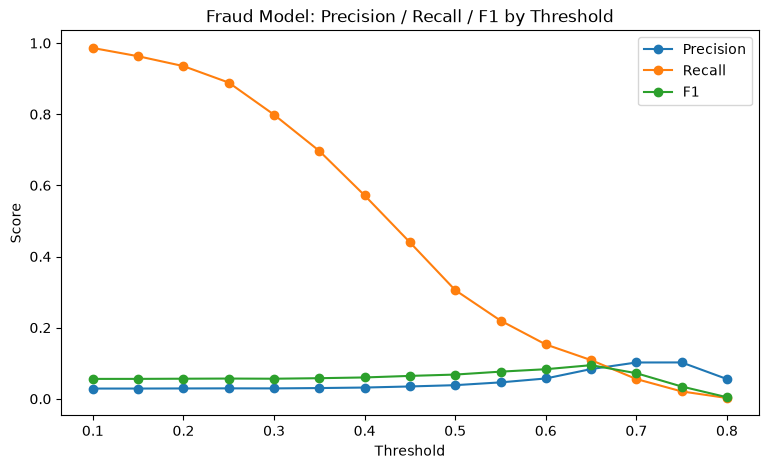

In [22]:
plt.figure(
    figsize=(9, 5)
)

plt.plot(
    threshold_df["THRESHOLD"],
    threshold_df["PRECISION"],
    marker="o",
    label="Precision",
)

plt.plot(
    threshold_df["THRESHOLD"],
    threshold_df["RECALL"],
    marker="o",
    label="Recall",
)

plt.plot(
    threshold_df["THRESHOLD"],
    threshold_df["F1"],
    marker="o",
    label="F1",
)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title(
    "Fraud Model: Precision / Recall / F1 by Threshold"
)
plt.legend()
plt.show()

## 20. Select threshold

For the first project version, select the threshold with the best F1 score.

In production, threshold selection should reflect:
- investigator capacity
- false-positive cost
- missed-fraud cost
- business policy

In [23]:
best_threshold_row = (
    threshold_df
    .sort_values(
        ["F1", "RECALL"],
        ascending=False
    )
    .iloc[0]
)

fraud_threshold = float(
    best_threshold_row[
        "THRESHOLD"
    ]
)

print(
    "Selected fraud threshold:",
    fraud_threshold
)

display(
    best_threshold_row.to_frame(
        "VALUE"
    )
)

Selected fraud threshold: 0.65


,VALUE
THRESHOLD,0.650000
PRECISION,0.083630
RECALL,0.108796
F1,0.094567
ALERT_COUNT,562.000000


## 21. Evaluate XGBoost at selected threshold

In [24]:
selected_threshold_metrics = evaluate_model(
    "XGBoost - Tuned Threshold",
    xgb_pipeline,
    X_test,
    y_test,
    threshold=fraud_threshold,
)


XGBoost - Tuned Threshold
THRESHOLD: 0.65
ACCURACY: 0.94
PRECISION: 0.0836
RECALL: 0.1088
F1: 0.0946
ROC_AUC: 0.5525
PR_AUC: 0.0433

Confusion Matrix:
[[14053   515]
 [  385    47]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.96      0.97     14568
           1       0.08      0.11      0.09       432

    accuracy                           0.94     15000
   macro avg       0.53      0.54      0.53     15000
weighted avg       0.95      0.94      0.94     15000



## 22. Feature importance

In [25]:
feature_names = (
    xgb_pipeline
    .named_steps[
        "preprocessor"
    ]
    .get_feature_names_out()
)

xgb_model = (
    xgb_pipeline
    .named_steps[
        "model"
    ]
)

feature_importance = pd.DataFrame({
    "FEATURE":
        feature_names,

    "IMPORTANCE":
        xgb_model.feature_importances_,
})

feature_importance[
    "FEATURE"
] = (
    feature_importance[
        "FEATURE"
    ]
    .str.replace(
        "num__",
        "",
        regex=False
    )
    .str.replace(
        "cat__",
        "",
        regex=False
    )
)

feature_importance = (
    feature_importance
    .sort_values(
        "IMPORTANCE",
        ascending=False
    )
)

display(
    feature_importance.head(20)
)

,FEATURE,IMPORTANCE
0,CLAIM_AMOUNT,0.022170
67,RISK_BAND_Medium,0.019687
56,POLICY_TYPE_Motor,0.019227
6,SUM_INSURED,0.018827
41,STATE_Karnataka,0.018041
24,CLAIM_SEVERITY_Low,0.017846
14,CLAIM_TYPE_Theft,0.017652
62,PAYMENT_MODE_Half-Yearly,0.017207
23,CLAIM_SEVERITY_High,0.017148
46,STATE_Tamil Nadu,0.017081


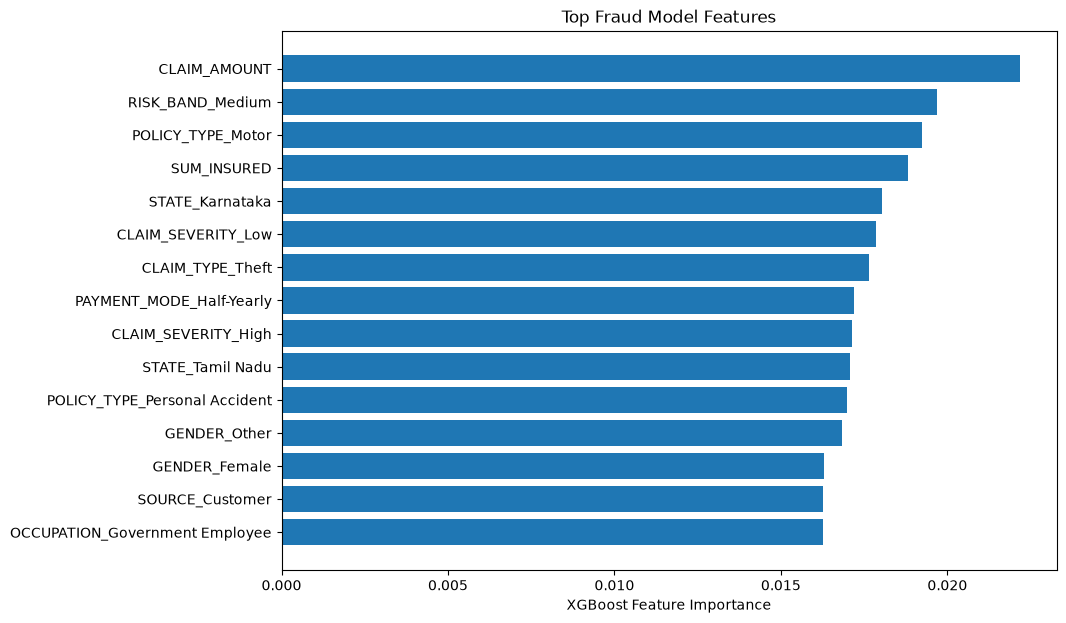

In [26]:
top_features = (
    feature_importance
    .head(15)
    .sort_values(
        "IMPORTANCE"
    )
)

plt.figure(
    figsize=(10, 7)
)

plt.barh(
    top_features["FEATURE"],
    top_features["IMPORTANCE"]
)

plt.title(
    "Top Fraud Model Features"
)

plt.xlabel(
    "XGBoost Feature Importance"
)

plt.show()

> Feature importance shows predictive usefulness. It does **not** prove causality.

## 23. Save fraud model dataset

In [27]:
fraud_model_dataset = fraud_df[
    [
        "CLAIM_ID",
        "POLICY_ID",
        "CUSTOMER_ID",
    ]
    + all_features
    + [
        "FRAUD_ALERT_FLAG"
    ]
].copy()

fraud_model_dataset.to_csv(
    CURATED_DIR
    / "fraud_model_dataset.csv",
    index=False
)

print(
    "Saved:",
    CURATED_DIR
    / "fraud_model_dataset.csv"
)

print(
    "Shape:",
    fraud_model_dataset.shape
)

Saved: f:\insurance_ai_copilot\data\curated\fraud_model_dataset.csv
Shape: (75000, 24)


## 24. Save production model + threshold

In [28]:
# Save COMPLETE preprocessing + XGBoost pipeline

joblib.dump(
    xgb_pipeline,
    MODELS_DIR
    / "fraud_xgboost_model.joblib"
)

joblib.dump(
    fraud_threshold,
    MODELS_DIR
    / "fraud_threshold.joblib"
)

print(
    "Saved fraud model:",
    MODELS_DIR
    / "fraud_xgboost_model.joblib"
)

print(
    "Saved fraud threshold:",
    MODELS_DIR
    / "fraud_threshold.joblib"
)

Saved fraud model: f:\insurance_ai_copilot\models\fraud_xgboost_model.joblib
Saved fraud threshold: f:\insurance_ai_copilot\models\fraud_threshold.joblib


## 25. Reload artifacts and validate

In [29]:
loaded_fraud_model = joblib.load(
    MODELS_DIR
    / "fraud_xgboost_model.joblib"
)

loaded_fraud_threshold = joblib.load(
    MODELS_DIR
    / "fraud_threshold.joblib"
)

print(
    "Loaded model type:",
    type(
        loaded_fraud_model
    )
)

print(
    "Loaded threshold:",
    loaded_fraud_threshold
)

print(
    "Pipeline feature count:",
    len(
        loaded_fraud_model.feature_names_in_
    )
)

print(
    "Pipeline features:"
)

print(
    list(
        loaded_fraud_model.feature_names_in_
    )
)

Loaded model type: <class 'sklearn.pipeline.Pipeline'>
Loaded threshold: 0.65
Pipeline feature count: 20
Pipeline features:
['CLAIM_AMOUNT', 'REPORTING_DELAY_DAYS', 'INCIDENT_MONTH', 'AGE', 'ANNUAL_INCOME', 'CREDIT_SCORE', 'SUM_INSURED', 'ANNUAL_PREMIUM', 'RISK_SCORE', 'CLAIM_TYPE', 'SOURCE', 'CLAIM_SEVERITY', 'GENDER', 'MARITAL_STATUS', 'OCCUPATION', 'STATE', 'CUSTOMER_RISK_SEGMENT', 'POLICY_TYPE', 'PAYMENT_MODE', 'RISK_BAND']


## 26. Test one real claim

In [30]:
sample_X = X_test.iloc[
    [0]
]

sample_probability = float(
    loaded_fraud_model
    .predict_proba(
        sample_X
    )[0, 1]
)

sample_prediction = int(
    sample_probability
    >= loaded_fraud_threshold
)

print(
    "Fraud probability:",
    round(
        sample_probability,
        4
    )
)

print(
    "Fraud risk %:",
    round(
        sample_probability * 100,
        2
    )
)

print(
    "Fraud alert:",
    sample_prediction
)

print()
print(
    "Reminder: 1 means the claim should be "
    "screened/investigated. It is NOT proof of fraud."
)

Fraud probability: 0.4486
Fraud risk %: 44.86
Fraud alert: 0

Reminder: 1 means the claim should be screened/investigated. It is NOT proof of fraud.


# Stage 13 Complete

After successful execution you should have:

```text
models/
├── renewal_xgboost_model.joblib
├── renewal_churn_threshold.joblib
├── fraud_xgboost_model.joblib
└── fraud_threshold.joblib

data/curated/
└── fraud_model_dataset.csv
```

## Next
1. Test `src/models/fraud_predictor.py`
2. Build `14_underwriting_model.ipynb`
3. Validate all model artifacts
4. Return to Fraud + Underwriting services / FastAPI
5. Continue from the Agentic AI stage where we paused